Nama: Prieyuda Akadita S
NIM: 240401010353
Kelas: IF403

In [1]:
print("Install library harap tunggu...")
!python -m pip install -q pandas seaborn matplotlib scikit-learn
print("Library berhasil diinstall!")

Install library harap tunggu...
Library berhasil diinstall!



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Memuat dataset titanic
df = sns.load_dataset("titanic")

# Pilih kolom yang akan digunakan
cols = ["pclass", "sex", "age", "sibsp", "parch", "fare", "embarked", "survived"]
df = df[cols].copy()

print("Shape:", df.shape)


Shape: (891, 8)


In [3]:
print("Missing values:")
print(df.isnull().sum())
print("\nDistribusi target:")
print(df["survived"].value_counts(normalize=True).round(3))



Missing values:
pclass        0
sex           0
age         177
sibsp         0
parch         0
fare          0
embarked      2
survived      0
dtype: int64

Distribusi target:
survived
0    0.616
1    0.384
Name: proportion, dtype: float64


In [4]:
# Age: isi dengan median
df["age"] = df["age"].fillna(df["age"].median())

# Embarked: isi dengan modus
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

print("Missing setelah handling:")
print(df.isnull().sum())  # Semua harus 0



Missing setelah handling:
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
survived    0
dtype: int64


In [5]:
# One-Hot Encoding untuk 'sex' dan 'embarked'
df = pd.get_dummies(df, columns=["sex", "embarked"], drop_first=True, dtype=int)

print("Kolom setelah encoding:")
print(df.columns.tolist())

Kolom setelah encoding:
['pclass', 'age', 'sibsp', 'parch', 'fare', 'survived', 'sex_male', 'embarked_Q', 'embarked_S']


## 3. Train-Test Split

Membagi data menjadi **Training Set (80%)** dan **Testing Set (20%)** dengan menggunakan `stratify=y` agar proporsi kelas target (`survived`) tetap terjaga di kedua subset.

In [6]:
from sklearn.model_selection import train_test_split

X = df.drop("survived", axis=1)
y = df["survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # proporsi kelas terjaga
)

print(f"Train: {X_train.shape[0]} baris")
print(f"Test : {X_test.shape[0]} baris")
print("\nProporsi survived di Train:")
print(y_train.value_counts(normalize=True).round(3))
print("\nProporsi survived di Test:")
print(y_test.value_counts(normalize=True).round(3))

Train: 712 baris
Test : 179 baris

Proporsi survived di Train:
survived
0    0.617
1    0.383
Name: proportion, dtype: float64

Proporsi survived di Test:
survived
0    0.615
1    0.385
Name: proportion, dtype: float64


## 4. Feature Scaling

Melakukan standardisasi (`StandardScaler`) **hanya pada kolom numerik kontinu**.
> **Catatan Penting:** Proses `fit_transform` hanya dilakukan pada `X_train`, sedangkan `X_test` hanya menggunakan `transform` agar tidak terjadi *data leakage*.

In [7]:
from sklearn.preprocessing import StandardScaler

# Hanya kolom numerik yang perlu di-scale (kolom biner TIDAK perlu)
num_cols = ["pclass", "age", "sibsp", "parch", "fare"]
scaler = StandardScaler()

# fit_transform pada training set (belajar μ dan σ dari sini)
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])

# transform saja pada test set (gunakan μ dan σ dari training!)
X_test[num_cols] = scaler.transform(X_test[num_cols])

print("Mean scaler (dari train):", scaler.mean_.round(2))
print("Std scaler (dari train):", scaler.scale_.round(2))
print()
print("Contoh X_train setelah scaling:")
print(X_train.head(3).round(3))

Mean scaler (dari train): [ 2.31 29.46  0.49  0.39 31.82]
Std scaler (dari train): [ 0.83 13.03  1.06  0.84 48.03]

Contoh X_train setelah scaling:
     pclass    age  sibsp  parch   fare  sex_male  embarked_Q  embarked_S
692   0.830 -0.112 -0.465 -0.466  0.514         1           0           1
481  -0.371 -0.112 -0.465 -0.466 -0.663         1           0           1
527  -1.571 -0.112 -0.465 -0.466  3.955         1           0           1


## Kesimpulan

Data telah selesai diproses dan siap digunakan untuk melatih model Machine Learning!

In [8]:
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")

X_train: (712, 8), y_train: (712,)


C:\Users\Prieyuda Akadita S\AppData\Local\Temp\ipykernel_1468\3255244701.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="survived", palette="Set2", ax=axes[0])


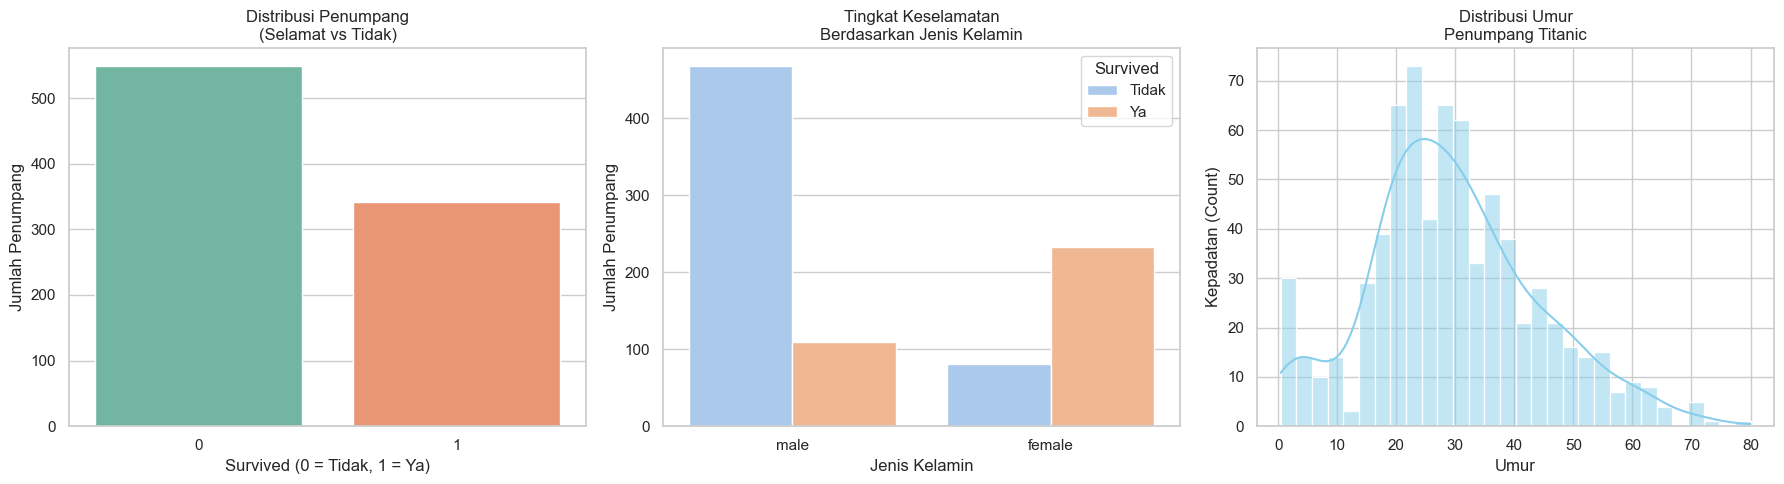

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Grafik Distribusi Target (Survived)
sns.countplot(data=df, x="survived", palette="Set2", ax=axes[0])
axes[0].set_title("Distribusi Penumpang\n(Selamat vs Tidak)")
axes[0].set_xlabel("Survived (0 = Tidak, 1 = Ya)")
axes[0].set_ylabel("Jumlah Penumpang")

# 2. Grafik Hubungan Jenis Kelamin & Keselamatan
# Catatan: Menggunakan data asli 'sex' sebelum di-encode agar grafik mudah dibaca
df_asli = sns.load_dataset("titanic")
sns.countplot(data=df_asli, x="sex", hue="survived", palette="pastel", ax=axes[1])
axes[1].set_title("Tingkat Keselamatan\nBerdasarkan Jenis Kelamin")
axes[1].set_xlabel("Jenis Kelamin")
axes[1].set_ylabel("Jumlah Penumpang")
axes[1].legend(title="Survived", labels=["Tidak", "Ya"])

# 3. Grafik Distribusi Umur
sns.histplot(data=df_asli, x="age", kde=True, color="skyblue", bins=30, ax=axes[2])
axes[2].set_title("Distribusi Umur\nPenumpang Titanic")
axes[2].set_xlabel("Umur")
axes[2].set_ylabel("Kepadatan (Count)")


plt.tight_layout()
plt.show()